In [151]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import pandas as pd
import numpy as np
import math

In [152]:
df=pd.read_csv('AdaBoost.csv')
df

,Age,Likes Height,Likes Goats,Climbed Meters
0,23,0,0,200
1,31,1,1,700
2,35,1,0,600
3,35,0,0,300
4,42,0,0,200
5,43,1,1,700
6,45,0,1,300
7,46,1,1,700
8,46,1,0,600
9,51,1,1,700


In [153]:
df['Weights1']=(np.ones(10))/10
X=df[['Age','Likes Height','Likes Goats']]
y=df['Climbed Meters']

In [154]:
df

,Age,Likes Height,Likes Goats,Climbed Meters,Weights1
0,23,0,0,200,0.1
1,31,1,1,700,0.1
2,35,1,0,600,0.1
3,35,0,0,300,0.1
4,42,0,0,200,0.1
5,43,1,1,700,0.1
6,45,0,1,300,0.1
7,46,1,1,700,0.1
8,46,1,0,600,0.1
9,51,1,1,700,0.1


In [155]:
model_0=DecisionTreeRegressor(max_depth=3,random_state=42)
model_0.fit(X,y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [156]:
y_pred1=model_0.predict(X)

In [157]:
df['y_pred1']=y_pred1

[Text(0.5555555555555556, 0.875, 'Likes Height <= 0.5\nsquared_error = 44000.0\nsamples = 10\nvalue = 500.0'),
 Text(0.3333333333333333, 0.625, 'Likes Goats <= 0.5\nsquared_error = 2500.0\nsamples = 4\nvalue = 250.0'),
 Text(0.4444444444444444, 0.75, 'True  '),
 Text(0.2222222222222222, 0.375, 'Age <= 29.0\nsquared_error = 2222.222\nsamples = 3\nvalue = 233.333'),
 Text(0.1111111111111111, 0.125, 'squared_error = 0.0\nsamples = 1\nvalue = 200.0'),
 Text(0.3333333333333333, 0.125, 'squared_error = 2500.0\nsamples = 2\nvalue = 250.0'),
 Text(0.4444444444444444, 0.375, 'squared_error = 0.0\nsamples = 1\nvalue = 300.0'),
 Text(0.7777777777777778, 0.625, 'Likes Goats <= 0.5\nsquared_error = 2222.222\nsamples = 6\nvalue = 666.667'),
 Text(0.6666666666666667, 0.75, '  False'),
 Text(0.6666666666666666, 0.375, 'squared_error = 0.0\nsamples = 2\nvalue = 600.0'),
 Text(0.8888888888888888, 0.375, 'squared_error = 0.0\nsamples = 4\nvalue = 700.0')]

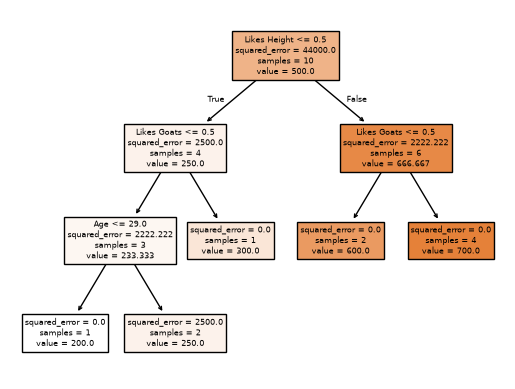

In [158]:
plot_tree(model_0,feature_names=['Age','Likes Height','Likes Goats'], class_names=['Climbed Meters'], filled=True)

In [159]:
n=0
df['Accuracy'] = np.where(df['Climbed Meters'] == df['y_pred1'], 1, 0)

n = (df['Accuracy'] == 0).sum()

In [160]:
df

,Age,Likes Height,Likes Goats,Climbed Meters,Weights1,y_pred1,Accuracy
0,23,0,0,200,0.1,200.0,1
1,31,1,1,700,0.1,700.0,1
2,35,1,0,600,0.1,600.0,1
3,35,0,0,300,0.1,250.0,0
4,42,0,0,200,0.1,250.0,0
5,43,1,1,700,0.1,700.0,1
6,45,0,1,300,0.1,300.0,1
7,46,1,1,700,0.1,700.0,1
8,46,1,0,600,0.1,600.0,1
9,51,1,1,700,0.1,700.0,1


In [161]:
error= n/10
error

np.float64(0.2)

In [162]:
alpha=0.5*math.log((1-error)/error) # influence of the Decision Tree



df['New_Weights']=np.where(df['Accuracy']==1,math.exp(-alpha),math.exp(alpha))

In [163]:
df

,Age,Likes Height,Likes Goats,Climbed Meters,Weights1,y_pred1,Accuracy,New_Weights
0,23,0,0,200,0.1,200.0,1,0.5
1,31,1,1,700,0.1,700.0,1,0.5
2,35,1,0,600,0.1,600.0,1,0.5
3,35,0,0,300,0.1,250.0,0,2.0
4,42,0,0,200,0.1,250.0,0,2.0
5,43,1,1,700,0.1,700.0,1,0.5
6,45,0,1,300,0.1,300.0,1,0.5
7,46,1,1,700,0.1,700.0,1,0.5
8,46,1,0,600,0.1,600.0,1,0.5
9,51,1,1,700,0.1,700.0,1,0.5


In [164]:
# normalizing the weights
df['New_Weights']=df['New_Weights']/np.sum(df['New_Weights'])

In [165]:
df

,Age,Likes Height,Likes Goats,Climbed Meters,Weights1,y_pred1,Accuracy,New_Weights
0,23,0,0,200,0.1,200.0,1,0.0625
1,31,1,1,700,0.1,700.0,1,0.0625
2,35,1,0,600,0.1,600.0,1,0.0625
3,35,0,0,300,0.1,250.0,0,0.2500
4,42,0,0,200,0.1,250.0,0,0.2500
5,43,1,1,700,0.1,700.0,1,0.0625
6,45,0,1,300,0.1,300.0,1,0.0625
7,46,1,1,700,0.1,700.0,1,0.0625
8,46,1,0,600,0.1,600.0,1,0.0625
9,51,1,1,700,0.1,700.0,1,0.0625


# Resampling df via Cumulative Weights (or Bins)

In [166]:

df_next_tree = df.sample(n=len(df), replace=True, weights='New_Weights').reset_index(drop=True)

In [167]:
df_next_tree=df_next_tree.drop(['Weights1','New_Weights','y_pred1','Accuracy'],axis=1)

# Second Tree

In [168]:
df_next_tree['Weights1']=(np.ones(10))/10
X=df_next_tree[['Age','Likes Height','Likes Goats']]
y=df_next_tree['Climbed Meters']

In [169]:
df_next_tree

,Age,Likes Height,Likes Goats,Climbed Meters,Weights1
0,51,1,1,700,0.1
1,51,1,1,700,0.1
2,35,0,0,300,0.1
3,31,1,1,700,0.1
4,23,0,0,200,0.1
5,35,0,0,300,0.1
6,42,0,0,200,0.1
7,43,1,1,700,0.1
8,42,0,0,200,0.1
9,43,1,1,700,0.1


In [170]:
model_1=DecisionTreeRegressor(max_depth=3,random_state=42)
model_1.fit(X,y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [171]:
y_pred1=model_1.predict(X)

In [172]:
df_next_tree['y_pred1']=y_pred1

[Text(0.5555555555555556, 0.875, 'Likes Height <= 0.5\nsquared_error = 44000.0\nsamples = 10\nvalue = 500.0'),
 Text(0.3333333333333333, 0.625, 'Likes Goats <= 0.5\nsquared_error = 2500.0\nsamples = 4\nvalue = 250.0'),
 Text(0.4444444444444444, 0.75, 'True  '),
 Text(0.2222222222222222, 0.375, 'Age <= 29.0\nsquared_error = 2222.222\nsamples = 3\nvalue = 233.333'),
 Text(0.1111111111111111, 0.125, 'squared_error = 0.0\nsamples = 1\nvalue = 200.0'),
 Text(0.3333333333333333, 0.125, 'squared_error = 2500.0\nsamples = 2\nvalue = 250.0'),
 Text(0.4444444444444444, 0.375, 'squared_error = 0.0\nsamples = 1\nvalue = 300.0'),
 Text(0.7777777777777778, 0.625, 'Likes Goats <= 0.5\nsquared_error = 2222.222\nsamples = 6\nvalue = 666.667'),
 Text(0.6666666666666667, 0.75, '  False'),
 Text(0.6666666666666666, 0.375, 'squared_error = 0.0\nsamples = 2\nvalue = 600.0'),
 Text(0.8888888888888888, 0.375, 'squared_error = 0.0\nsamples = 4\nvalue = 700.0')]

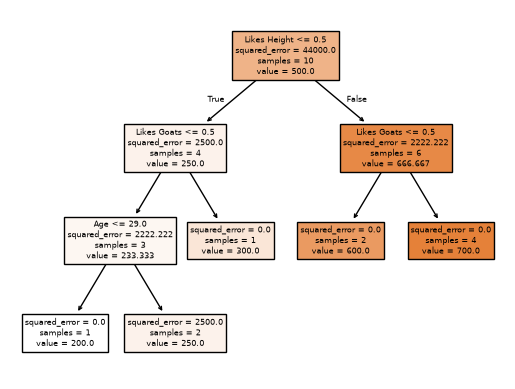

In [173]:
plot_tree(model_0,feature_names=['Age','Likes Height','Likes Goats'], class_names=['Climbed Meters'], filled=True)

In [174]:
n=0
df_next_tree['Accuracy'] = np.where(df_next_tree['Climbed Meters'] == df_next_tree['y_pred1'], 1, 0)

n = (df_next_tree['Accuracy'] == 0).sum()

In [175]:
df_next_tree

,Age,Likes Height,Likes Goats,Climbed Meters,Weights1,y_pred1,Accuracy
0,51,1,1,700,0.1,700.0,1
1,51,1,1,700,0.1,700.0,1
2,35,0,0,300,0.1,300.0,1
3,31,1,1,700,0.1,700.0,1
4,23,0,0,200,0.1,200.0,1
5,35,0,0,300,0.1,300.0,1
6,42,0,0,200,0.1,200.0,1
7,43,1,1,700,0.1,700.0,1
8,42,0,0,200,0.1,200.0,1
9,43,1,1,700,0.1,700.0,1


In [176]:
error= n/10
error

np.float64(0.0)

In [177]:
alpha=0.5*math.log((1-error)/error) # influence of the Decision Tree



df_next_tree['New_Weights']=np.where(df_next_tree['Accuracy']==1,math.exp(-alpha),math.exp(alpha))

C:\Users\DELL\AppData\Local\Temp\ipykernel_12300\1272304524.py:1: RuntimeWarning: divide by zero encountered in scalar divide
  alpha=0.5*math.log((1-error)/error) # influence of the Decision Tree


In [178]:
df_next_tree

,Age,Likes Height,Likes Goats,Climbed Meters,Weights1,y_pred1,Accuracy,New_Weights
0,51,1,1,700,0.1,700.0,1,0.0
1,51,1,1,700,0.1,700.0,1,0.0
2,35,0,0,300,0.1,300.0,1,0.0
3,31,1,1,700,0.1,700.0,1,0.0
4,23,0,0,200,0.1,200.0,1,0.0
5,35,0,0,300,0.1,300.0,1,0.0
6,42,0,0,200,0.1,200.0,1,0.0
7,43,1,1,700,0.1,700.0,1,0.0
8,42,0,0,200,0.1,200.0,1,0.0
9,43,1,1,700,0.1,700.0,1,0.0


In [179]:
# normalizing the weights
df_next_tree['New_Weights']=df_next_tree['New_Weights']/np.sum(df_next_tree['New_Weights'])

In [180]:
df_next_tree

,Age,Likes Height,Likes Goats,Climbed Meters,Weights1,y_pred1,Accuracy,New_Weights
0,51,1,1,700,0.1,700.0,1,NaN
1,51,1,1,700,0.1,700.0,1,NaN
2,35,0,0,300,0.1,300.0,1,NaN
3,31,1,1,700,0.1,700.0,1,NaN
4,23,0,0,200,0.1,200.0,1,NaN
5,35,0,0,300,0.1,300.0,1,NaN
6,42,0,0,200,0.1,200.0,1,NaN
7,43,1,1,700,0.1,700.0,1,NaN
8,42,0,0,200,0.1,200.0,1,NaN
9,43,1,1,700,0.1,700.0,1,NaN
